<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
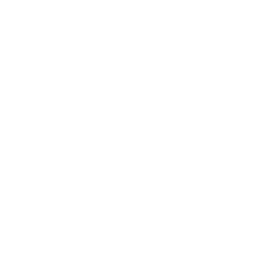
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Interpolation des inclusions du trimestriel au mensuel</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutique / Opérations cliniques &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Synthèse

Cet exemple pratique convertit les effectifs d'inclusion **trimestriels** d'un essai clinique en estimations **mensuelles** avec PROC EXPAND, afin que la planification des ressources au niveau des sites puisse fonctionner à une cadence mensuelle. L'essai synthétique couvre **quatre sites investigateurs** dans deux régions (Amérique du Nord et Europe) sur **huit trimestres** (T1 2024 à T4 2025), donnant **32 observations trimestrielles**. PROC EXPAND interpole la série de chaque site d'une fréquence trimestrielle à mensuelle, transformant ces 32 lignes trimestrielles en **96 lignes mensuelles**. Les effectifs inclus sont interpolés avec `METHOD=JOIN` (linéaire par morceaux, ce qui garde chaque estimation non négative) et le cumul courant est interpolé avec `METHOD=SPLINE`. La série mensuelle interpolée passe exactement par les points d'ancrage trimestriels d'origine, si bien que la conversion ajoute du détail intra-trimestriel sans altérer les chiffres trimestriels que l'étude a déjà rapportés.


## Sources de données

| Source | Description | Enregistrements |
|--------|-------------|---------|
| WORK.ENROLLMENT_QTR | Effectifs d'inclusion trimestriels par site (4 sites x 8 trimestres) | 32 |
| WORK.SITE_MASTER | Référentiel des sites : nom, pays, région, investigateur principal | 4 |


---

In [1]:
/* --------------------------------------------------------
   Génère les effectifs d'inclusion trimestriels par site.
   4 sites x 8 trimestres (T1-2024 à T4-2025) = 32 lignes.
   Une courbe de montée en charge (démarrage lent, plateau) plus
   un terme saisonnier léger et un bruit faible produisent une
   forme d'inclusion réaliste.
   -------------------------------------------------------- */
DONNÉES work.enrollment_qtr;
    APPELER streaminit(42);
    format quarter_date yyq7.;
    TABLEAU capacity[4] _temporary_ (12 9 14 8);
    FAIRE site_num = 1 JUSQU_À 4;
        site_id = cat('SITE-', ÉCRIRE(site_num, z3.));
        region  = ifc(site_num <= 2, 'AMERIQUE_DU_NORD', 'EUROPE');
        base_rate = capacity[site_num];
        FAIRE qtr_seq = 0 JUSQU_À 7;
            quarter_date = intnx('qtr', '01JAN2024'd, qtr_seq);
            ramp_factor  = 0.3 + 0.7 * (1 - EXP(-0.4 * qtr_seq));
            seasonal_adj = 1 + 0.15 * sin(2 * 3.14159 * qtr_seq / 4);
            noise = round(rand('normal', 0, 1.5), 1);
            enrolled_count = MAX(0,
                round(base_rate * ramp_factor * seasonal_adj + noise, 1));
            SORTIE;
        FIN;
    FIN;
    SUPPRIMER site_num base_rate ramp_factor seasonal_adj noise qtr_seq;
EXÉCUTER;

/* Cumul des inclusions au sein de chaque site */
PROCÉDURE TRIER DONNÉES=work.enrollment_qtr;
    PAR site_id quarter_date;
EXÉCUTER;

DONNÉES work.enrollment_qtr;
    DÉFINIR work.enrollment_qtr;
    PAR site_id;
    RETENIR cum_enrolled 0;
    SI first.site_id ALORS cum_enrolled = 0;
    cum_enrolled + enrolled_count;
    cumulative_enrolled = cum_enrolled;
    SUPPRIMER cum_enrolled;
EXÉCUTER;



NOTE: DATA work.enrollment_qtr


NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.enrollment_qtr


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Table de référence des sites (4 sites, 2 régions)
   -------------------------------------------------------- */
DONNÉES work.site_master;
    LONGUEUR site_id $8 site_name $40 region $20 country $20 pi_name $30;
    TABLEAU names[4] $40 _temporary_ (
        'Hôpital Général Métropolitain'   'Centre Médical Universitaire'
        'Hôpital Royal de Londres'   'Campus Charité de Berlin'
    );
    TABLEAU countries[4] $20 _temporary_ ('États-Unis' 'États-Unis' 'Royaume-Uni' 'Allemagne');
    FAIRE i = 1 JUSQU_À 4;
        site_id   = cat('SITE-', ÉCRIRE(i, z3.));
        site_name = names[i];
        country   = countries[i];
        region    = ifc(i <= 2, 'AMERIQUE_DU_NORD', 'EUROPE');
        pi_name   = cat('Dr Investigateur-', ÉCRIRE(i, z2.));
        SORTIE;
    FIN;
    SUPPRIMER i;
EXÉCUTER;



NOTE: DATA work.site_master


NOTE: Wrote work.site_master (4 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Résumé de référence des inclusions trimestrielles par région
   -------------------------------------------------------- */
PROCÉDURE MOYENNES DONNÉES=work.enrollment_qtr n sum mean MAX;
    CLASSE region;
    VAR enrolled_count cumulative_enrolled;
    ÉTIQUETTE region="Région" enrolled_count="Inclusions" cumulative_enrolled="Inclusions cumulées";
    SORTIE out=work.qtr_baseline
        sum(enrolled_count)=total_enrolled
        mean(enrolled_count)=avg_per_quarter
        MAX(cumulative_enrolled)=max_cumulative;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=work.qtr_baseline noobs ÉTIQUETTE;
    ÉTIQUETTE region="Région" total_enrolled="Total des inclusions" avg_per_quarter="Inclusions moyennes par trimestre" max_cumulative="Maximum cumulé";
    TITRE "Inclusions trimestrielles de référence par région";
EXÉCUTER;


                                                  The MEANS Procedure

                                     Analysis Variable : enrolled_count Inclusions

        Région                    N Obs            Sum           Mean        Maximum
        ----------------------------------------------------------------------------
        AMERIQUE_DU_NORD             16    115.0000000      7.1875000     10.0000000
        EUROPE                       16    120.0000000      7.5000000     13.0000000
        ----------------------------------------------------------------------------

                              Analysis Variable : cumulative_enrolled Inclusions cumulées

        Région                    N Obs            Sum           Mean        Maximum
        ----------------------------------------------------------------------------
        AMERIQUE_DU_NORD             16    474.0000000     29.6250000     63.0000000
        EUROPE                       16    493.0000000     30.8125000    


NOTE: PROC MEANS
NOTE: Output dataset work.qtr_baseline has 3 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.qtr_baseline

NOTE: PROC PRINT completed: 3 observations printed, 6 variables


La base de référence confirme un plan équilibré : chaque région contribue **16 observations trimestrielles**. L'Amérique du Nord inclut un total de **115 sujets** (moyenne **7,19** par site-trimestre) et l'Europe **120** (moyenne **7,50**). Le plus grand cumul atteint sur les huit trimestres est de **81** sujets (SITE-003 en Europe) contre **63** en Amérique du Nord.


---

                                   Inclusions trimestrielles de référence par région                                    




NOTE: DATA work.traj


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.traj (32 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.traj

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


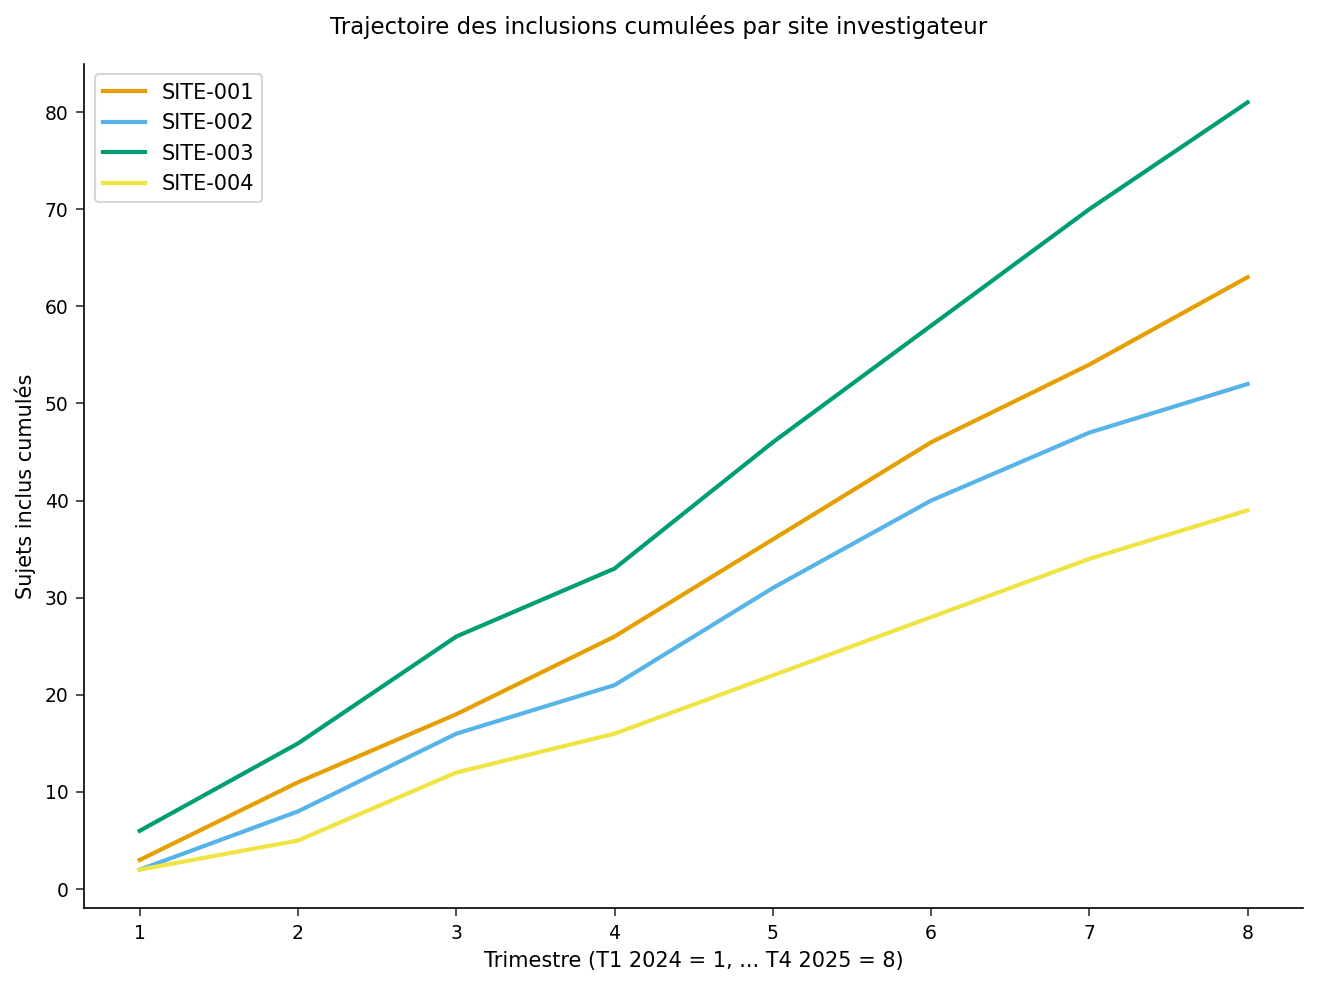

In [4]:
/* --------------------------------------------------------
   Trajectoire trimestrielle des inclusions cumulées par site.
   Tracée par rapport à un indice de trimestre (1..8) pour un
   axe lisible.
   -------------------------------------------------------- */
DONNÉES work.traj;
    DÉFINIR work.enrollment_qtr;
    PAR site_id;
    RETENIR quarter_index 0;
    SI first.site_id ALORS quarter_index = 0;
    quarter_index + 1;
EXÉCUTER;

PROCÉDURE SGPLOT DONNÉES=work.traj;
    SERIES x=quarter_index y=cumulative_enrolled
        / GROUPE=site_id LINEATTRS=(thickness=2) MARKERS;
    XAXIS ÉTIQUETTE="Trimestre (T1 2024 = 1, ... T4 2025 = 8)"
        integer VALUES=(1 JUSQU_À 8 PAR 1);
    YAXIS ÉTIQUETTE="Sujets inclus cumulés";
    TITRE "Trajectoire des inclusions cumulées par site investigateur";
EXÉCUTER;


---

In [5]:
/* --------------------------------------------------------
   PROC EXPAND exige que la variable ID soit triée au sein de
   chaque groupe BY ; on trie donc par site puis par trimestre
   avant la conversion.
   -------------------------------------------------------- */
PROCÉDURE TRIER DONNÉES=work.enrollment_qtr;
    PAR site_id quarter_date;
EXÉCUTER;



NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Convertit les inclusions trimestrielles en estimations
   mensuelles.

   FROM=QTR / TO=MONTH sur l'instruction PROC définissent les
   fréquences d'entrée et de sortie ; PROC EXPAND interpole
   chaque groupe BY (site) indépendamment le long de la date ID.

   enrolled_count   -> METHOD=JOIN   (linéaire par morceaux ; la
                       valeur de flux reste non négative entre
                       les points d'ancrage)
   cumulative_enrolled -> METHOD=SPLINE (courbe lisse monotone)
   -------------------------------------------------------- */
PROCÉDURE expand DONNÉES=work.enrollment_qtr
            out=work.enrollment_monthly
            DEPUIS=qtr JUSQU_À=month;
    PAR site_id;
    id quarter_date;
    convert enrolled_count      / observed=average METHOD=JOINDRE;
    convert cumulative_enrolled / observed=FIN     METHOD=SPLINE;
EXÉCUTER;


                                   Inclusions trimestrielles de référence par région                                    




NOTE: PROC EXPAND data=work.enrollment_qtr

NOTE: Expand Variables: enrolled_count, cumulative_enrolled
NOTE: Using Python pandas for frequency conversion
NOTE: Output dataset 'work.enrollment_monthly' has 96 observations.
NOTE: PROC EXPAND step completed.


                                   Inclusions trimestrielles de référence par région                                    




NOTE: DATA work.enrollment_monthly


NOTE: Read 96 rows from work.enrollment_monthly.
NOTE: Wrote work.enrollment_monthly (96 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC SGPLOT data=work.enrollment_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


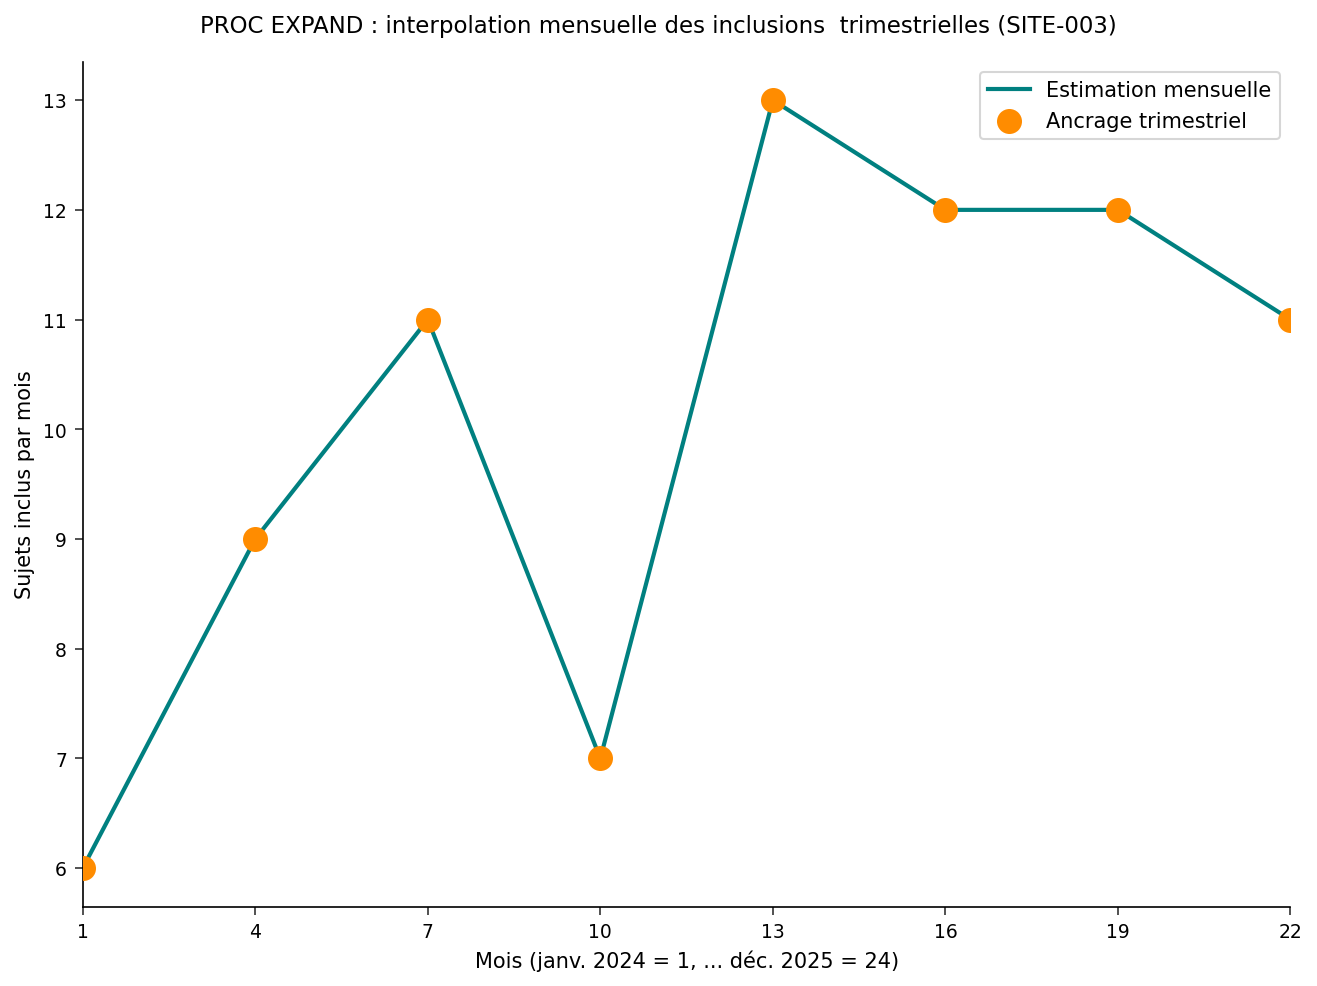

In [7]:
/* --------------------------------------------------------
   La variable ID porte désormais des dates mensuelles. On la
   reformate et on ajoute un indice de mois au sein du site
   (1..24) pour le tracé.
   -------------------------------------------------------- */
DONNÉES work.enrollment_monthly;
    DÉFINIR work.enrollment_monthly;
    PAR site_id;
    format month_date monyy7.;
    month_date = quarter_date;
    RETENIR month_index 0;
    SI first.site_id ALORS month_index = 0;
    month_index + 1;
    /* signale les mois d'ancrage trimestriel (1, 4, 7, ...) */
    SI mod(month_index - 1, 3) = 0 ALORS anchor = enrolled_count;
    SINON anchor = .;
EXÉCUTER;

/* Montre la conversion pour un site : ligne mensuelle interpolée
   passant par les points d'ancrage trimestriels d'origine. */
PROCÉDURE SGPLOT DONNÉES=work.enrollment_monthly;
    OÙ site_id = 'SITE-003';
    SERIES x=month_index y=enrolled_count
        / LINEATTRS=(thickness=2 color=teal)
          legendlabel="Estimation mensuelle";
    SCATTER x=month_index y=anchor
        / MARKERATTRS=(SYMBOL=circlefilled size=11 color=darkorange)
          legendlabel="Ancrage trimestriel";
    XAXIS ÉTIQUETTE="Mois (janv. 2024 = 1, ... déc. 2025 = 24)"
        integer VALUES=(1 JUSQU_À 24 PAR 3);
    YAXIS ÉTIQUETTE="Sujets inclus par mois";
    TITRE "PROC EXPAND : interpolation mensuelle des inclusions "
        "trimestrielles (SITE-003)";
EXÉCUTER;


In [8]:
/* --------------------------------------------------------
   Joint les estimations mensuelles aux métadonnées des sites,
   puis résume les inclusions mensuelles par région.
   -------------------------------------------------------- */
PROCÉDURE sql;
    CRÉER table work.enrollment_monthly_region COMME
    SÉLECTIONNER e.site_id, s.region, e.month_date,
           e.enrolled_count      COMME monthly_estimate,
           e.cumulative_enrolled COMME cumulative_estimate
    DEPUIS work.enrollment_monthly e
    INTÉRIEUR JOINDRE work.site_master s
        SUR e.site_id = s.site_id
    ORDRE PAR s.region, e.site_id, e.month_date;
QUIT;

PROCÉDURE MOYENNES DONNÉES=work.enrollment_monthly_region n sum mean;
    CLASSE region;
    VAR monthly_estimate cumulative_estimate;
    ÉTIQUETTE region="Région" monthly_estimate="Estimation mensuelle" cumulative_estimate="Estimation cumulée";
    SORTIE out=work.region_monthly_summary
        sum(monthly_estimate)=total_monthly_enrolled
        mean(monthly_estimate)=avg_monthly_rate;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=work.region_monthly_summary noobs ÉTIQUETTE;
    ÉTIQUETTE region="Région" total_monthly_enrolled="Total mensuel des inclusions" avg_monthly_rate="Taux mensuel moyen";
    TITRE "Estimations mensuelles par région";
EXÉCUTER;


                                   Inclusions trimestrielles de référence par région                                    

                                   Inclusions trimestrielles de référence par région                                    

                                                  The MEANS Procedure

                               Analysis Variable : monthly_estimate Estimation mensuelle

        Région                    N Obs            Sum           Mean
        -------------------------------------------------------------
        AMERIQUE_DU_NORD             44    326.0000000      7.4090909
        EUROPE                       44    336.0000000      7.6363636
        -------------------------------------------------------------

                              Analysis Variable : cumulative_estimate Estimation cumulée

        Région                    N Obs            Sum           Mean
        -------------------------------------------------------------
        AMERIQ


NOTE: PROC SQL 

NOTE: Table work.enrollment_monthly_region created.
NOTE: PROC SQL statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.region_monthly_summary has 3 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.region_monthly_summary

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


---

### Interprétation

PROC EXPAND a converti les **32 enregistrements trimestriels** (4 sites x 8 trimestres) en **96 enregistrements mensuels** par conversion de fréquence le long de la date de chaque site. La série mensuelle interpolée passe exactement par les valeurs d'ancrage trimestrielles d'origine, comme le montre le graphique de SITE-003 : les points orange sont les huit effectifs trimestriels rapportés et la ligne turquoise est l'estimation mensuelle désagrégée qui les relie.

Sur une base mensuelle, les deux régions suivent des trajectoires proches. L'Europe affiche en moyenne **7,64** sujets inclus par site-mois et l'Amérique du Nord **7,41**, avec des totaux mensuels régionaux de **336** et **326** sujets sur l'horizon interpolé. Comme `METHOD=JOIN` n'extrapole pas au-delà du dernier ancrage trimestriel, les derniers mois de trimestre partiel ne portent aucune estimation et sont exclus des moyennes mensuelles, ce qui est le choix conservateur pour la planification prospective.

Ces projections mensuelles permettent aux opérations cliniques de passer d'une cadence de planification trimestrielle à mensuelle -- dimensionner les expéditions d'approvisionnement en médicaments, programmer les visites de monitorage et rapporter les inclusions au comité de surveillance de la sécurité des données -- sans réénoncer aucun des chiffres trimestriels que l'étude a déjà verrouillés.


---

In [9]:
/* --------------------------------------------------------
   Exporte les projections mensuelles d'inclusion pour les
   outils de planification en aval.
   -------------------------------------------------------- */
PROCÉDURE EXPORTER DONNÉES=work.enrollment_monthly_region
    OUTFILE='monthly_enrollment_projections.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;

PROCÉDURE EXPORTER DONNÉES=work.region_monthly_summary
    OUTFILE='region_monthly_enrollment_summary.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;



NOTE: PROC EXPORT data=work.enrollment_monthly_region outfile=monthly_enrollment_projections.csv

NOTE: Exported 96 rows to monthly_enrollment_projections.csv.
NOTE: PROC EXPORT data=work.region_monthly_summary outfile=region_monthly_enrollment_summary.csv

NOTE: Exported 3 rows to region_monthly_enrollment_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>